In [57]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from pathlib import Path
import json
import datetime
import re

In [ ]:
data_path =Path('..') / Path('data') / Path('sneakers_data.json')

In [59]:
with open(data_path, 'r', encoding='utf-8') as f:
    data = json.load(f)

df = pd.json_normalize(data)

df.head()

,slug,url,scraped_at,sales_series,errors,product_details.title,product_details.brand,product_details.traits.style,product_details.traits.colorway,product_details.traits.retail_price,...,_meta.retail_price,_meta.release_date,_meta.brand,_meta.title,_meta.series_count,_meta.has_errors,product_details.traits.included_accessories,product_details.traits.restock_date,product_details.traits.season,product_details.traits.color
0,air-jordan-1-low-midnight-navy-neutral-grey,https://stockx.com/air-jordan-1-low-midnight-n...,2026-06-17T03:25:27.852404+00:00,"[{'xValue': '2025-03-13T00:00:00.000Z', 'yValu...",[],Jordan 1 LowMidnight Navy Neutral Grey,None,553558-146,White/Neutral Grey/Gum Medium Brown/Midnight Navy,$125,...,$125,04/20/2025,None,Jordan 1 LowMidnight Navy Neutral Grey,100,False,NaN,NaN,NaN,NaN
1,air-jordan-1-retro-high-og-shattered-backboard...,https://stockx.com/air-jordan-1-retro-high-og-...,2026-06-16T02:53:09.759227+00:00,"[{'xValue': '2025-06-26T00:00:00.000Z', 'yValu...",[],Jordan 1 Retro High OGShattered Backboard (2025),None,DZ5485-008,Black/Black-Sail-Starfish,$180,...,$180,08/23/2025,None,Jordan 1 Retro High OGShattered Backboard (2025),100,False,Orange Laces,NaN,NaN,NaN
2,air-jordan-1-retro-high-og-sp-fragment-x-union...,https://stockx.com/air-jordan-1-retro-high-og-...,2026-06-16T02:53:12.844689+00:00,"[{'xValue': '2026-02-01T00:00:00.000Z', 'yValu...",[],Jordan 1 Retro High OG SPFragment x Union LA V...,None,IO7847-002,Black/White/Varsity Red/Sport Royal,$205,...,$205,02/27/2026,None,Jordan 1 Retro High OG SPFragment x Union LA V...,100,False,"Black Laces, Yellow Laces, Black/Red Laces",NaN,NaN,NaN
3,air-jordan-1-retro-high-virgil-abloh-archive-a...,https://stockx.com/air-jordan-1-retro-high-vir...,2026-06-16T02:53:17.434157+00:00,"[{'xValue': '2026-03-06T00:00:00.000Z', 'yValu...",[],Jordan 1 Retro HighVirgil Abloh Archive Alaska,None,AA3834-100,White/White,$230,...,$230,04/03/2026,None,Jordan 1 Retro HighVirgil Abloh Archive Alaska,100,False,"Blue Zip Tie, Black Laces, Purple Laces, Blue ...",NaN,NaN,NaN
4,air-jordan-1-retro-low-og-banned,https://stockx.com/air-jordan-1-retro-low-og-b...,2026-06-17T03:26:09.020156+00:00,"[{'xValue': '2026-04-09T00:00:00.000Z', 'yValu...",[],Jordan 1 Retro Low OGBanned,None,IW6276-001,Black/Black/Varsity Red/Summit White,$145,...,$145,05/02/2026,None,Jordan 1 Retro Low OGBanned,100,False,"White Laces, Red Laces",NaN,NaN,NaN


# Clean Data

In [60]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5013 entries, 0 to 5012
Data columns (total 25 columns):
 #   Column                                       Non-Null Count  Dtype 
---  ------                                       --------------  ----- 
 0   slug                                         5013 non-null   object
 1   url                                          5013 non-null   object
 2   scraped_at                                   5013 non-null   object
 3   sales_series                                 5013 non-null   object
 4   errors                                       5013 non-null   object
 5   product_details.title                        5009 non-null   object
 6   product_details.brand                        0 non-null      object
 7   product_details.traits.style                 4988 non-null   object
 8   product_details.traits.colorway              4981 non-null   object
 9   product_details.traits.retail_price          4984 non-null   object
 10  product_deta

## General Quality

In [61]:
df.shape

(5013, 25)

In [62]:
df['product_details.source'].value_counts()

product_details.source
html_section    5009
not_found          4
Name: count, dtype: int64

In [63]:
df.drop(df[df['product_details.source'] == 'not_found'].index, inplace=True)

In [64]:
df[df['product_details.source'] == 'not_found']

,slug,url,scraped_at,sales_series,errors,product_details.title,product_details.brand,product_details.traits.style,product_details.traits.colorway,product_details.traits.retail_price,...,_meta.retail_price,_meta.release_date,_meta.brand,_meta.title,_meta.series_count,_meta.has_errors,product_details.traits.included_accessories,product_details.traits.restock_date,product_details.traits.season,product_details.traits.color


In [65]:
len(df[df['_meta.has_errors']== True])

4

In [66]:
df.drop(df[df['_meta.has_errors']== True].index, inplace=True)

In [67]:
len(df[df['_meta.has_errors']== True])

0

Only 8 rows has been deleted

## Looking for NaNs

In [68]:
df.isna().sum()

slug                                              0
url                                               0
scraped_at                                        0
sales_series                                      0
errors                                            0
product_details.title                             0
product_details.brand                          5005
product_details.traits.style                     21
product_details.traits.colorway                  28
product_details.traits.retail_price              25
product_details.traits.release_date             365
product_details.description                    2006
product_details.source                            0
_meta.style                                      21
_meta.colorway                                   28
_meta.retail_price                               25
_meta.release_date                              365
_meta.brand                                    5005
_meta.title                                       0
_meta.series

## Use only the most interesting columns

In [69]:
columns_to_use = [
    'sales_series',
    'product_details.title',
    'product_details.traits.retail_price',
    'product_details.traits.release_date'
    ]

In [70]:
df = df[columns_to_use]
df.head()

,sales_series,product_details.title,product_details.traits.retail_price,product_details.traits.release_date
0,"[{'xValue': '2025-03-13T00:00:00.000Z', 'yValu...",Jordan 1 LowMidnight Navy Neutral Grey,$125,04/20/2025
1,"[{'xValue': '2025-06-26T00:00:00.000Z', 'yValu...",Jordan 1 Retro High OGShattered Backboard (2025),$180,08/23/2025
2,"[{'xValue': '2026-02-01T00:00:00.000Z', 'yValu...",Jordan 1 Retro High OG SPFragment x Union LA V...,$205,02/27/2026
3,"[{'xValue': '2026-03-06T00:00:00.000Z', 'yValu...",Jordan 1 Retro HighVirgil Abloh Archive Alaska,$230,04/03/2026
4,"[{'xValue': '2026-04-09T00:00:00.000Z', 'yValu...",Jordan 1 Retro Low OGBanned,$145,05/02/2026


In [71]:
df.columns = df.columns.str.replace(r'^product_details\.', '', regex=True)
df.columns = df.columns.str.replace(r'^traits\.', '', regex=True)

nuevas_columnas = ['title'] + [col for col in df.columns if col != 'title']
df = df[nuevas_columnas]

df.head()

,title,sales_series,retail_price,release_date
0,Jordan 1 LowMidnight Navy Neutral Grey,"[{'xValue': '2025-03-13T00:00:00.000Z', 'yValu...",$125,04/20/2025
1,Jordan 1 Retro High OGShattered Backboard (2025),"[{'xValue': '2025-06-26T00:00:00.000Z', 'yValu...",$180,08/23/2025
2,Jordan 1 Retro High OG SPFragment x Union LA V...,"[{'xValue': '2026-02-01T00:00:00.000Z', 'yValu...",$205,02/27/2026
3,Jordan 1 Retro HighVirgil Abloh Archive Alaska,"[{'xValue': '2026-03-06T00:00:00.000Z', 'yValu...",$230,04/03/2026
4,Jordan 1 Retro Low OGBanned,"[{'xValue': '2026-04-09T00:00:00.000Z', 'yValu...",$145,05/02/2026


In [72]:
df.isna().sum()

title             0
sales_series      0
retail_price     25
release_date    365
dtype: int64

### Drop useless sneakers

A sneaker is useless if it hasn't data about sales_series, retail_price and release_date

In [73]:
df[df['retail_price'].isna()]

,title,sales_series,retail_price,release_date
280,adidas Samba OGBambi Brown Desert (Women's),"[{'xValue': '2026-05-31T00:00:00.000Z', 'yValu...",NaN,NaN
756,adidas Superstar IIAnthony Edwards Navy Croc,"[{'xValue': '2026-02-01T00:00:00.000Z', 'yValu...",NaN,NaN
1533,Jordan 1 MidBlack Cool Grey Light Armoury Blue,"[{'xValue': '2026-04-26T00:00:00.000Z', 'yValu...",NaN,10/01/2022
1699,ASICS Superblast 3blacktoes Keep Running Quiet,"[{'xValue': '2026-05-30T00:00:00.000Z', 'yValu...",NaN,06/30/2026
2292,ASICS Gel-Kahana TR V4Ocean Green,"[{'xValue': '2024-06-22T00:00:00.000Z', 'yValu...",NaN,03/18/2024
2761,New Balance 740Timberwolf White,"[{'xValue': '2025-12-05T00:00:00.000Z', 'yValu...",NaN,NaN
3092,New Balance 997RCream,"[{'xValue': '2023-12-11T00:00:00.000Z', 'yValu...",NaN,NaN
3208,New Balance 1906Datmos Tokyo Deep Sea,"[{'xValue': '2024-12-21T00:00:00.000Z', 'yValu...",NaN,NaN
3215,New Balance 530Linen Stoneware,"[{'xValue': '2024-05-03T00:00:00.000Z', 'yValu...",NaN,NaN
3227,New Balance 9060Mono Black,"[{'xValue': '2025-12-10T00:00:00.000Z', 'yValu...",NaN,NaN


In [74]:
df.shape

(5005, 4)

In [75]:
condicion_lista_vacia = df['sales_series'].str.len() == 0
condicion_nulos = df['retail_price'].isna() & df['release_date'].isna()

filas_a_eliminar = condicion_lista_vacia & condicion_nulos

df_limpio = df[~filas_a_eliminar]

In [76]:
df_limpio.shape

(4996, 4)

In [77]:
df.shape[0] - df_limpio.shape[0] # only 9 rows were deleted

9

### Fill release_date using temporal series

In [78]:
df_limpio.isna().sum()

title             0
sales_series      0
retail_price     16
release_date    356
dtype: int64

In [79]:
df_limpio['release_date'].isna().sum()

np.int64(356)

In [80]:
(df_limpio['release_date'].isna().sum()/df_limpio.shape[0])*100

np.float64(7.125700560448359)

We cannot delete the 7% of the data

In [81]:
df_limpio[(df_limpio['release_date'].isna()) & (df_limpio['sales_series'].str.len() == 0)] # untrackable date, we delte them

,title,sales_series,retail_price,release_date
710,adidas Handball SpezialOlive Strata Acid Mint,[],$120,NaN
3156,New Balance 9060Lone Star,[],$150,NaN
4068,Nike Air Max 95 OGBig Bubble 7-Eleven,[],$210,NaN
4205,Puma Speedcat OGLilac Luster Lavender Pop,[],$100,NaN
4264,Puma Mostro MoveWhite Warm White (Women's),[],$120,NaN
...,...,...,...,...
4982,Puma CA MatchBMW Motorsport White Pro Blue,[],$90,NaN
4985,Puma Deviate Nitro 3Dusky Gray Heat Fire,[],$160,NaN
4990,Puma InhaleMint Melt Lavender Alert,[],$110,NaN
5000,Puma RoyalOrange Glo Black,[],$75,NaN


In [82]:
74/df_limpio.shape[0] * 100

1.4811849479583667

In [83]:
condicion_lista_vacia = df_limpio['sales_series'].str.len() == 0
condicion_nulos = df_limpio['release_date'].isna()

filas_a_eliminar = condicion_lista_vacia & condicion_nulos

df_limpio = df_limpio[~filas_a_eliminar]

#### Try to fill the gaps using the time serie

In [84]:
df_limpio[(df_limpio['release_date'].isna()) & (df_limpio['sales_series'].str.len() > 0)]

,title,sales_series,retail_price,release_date
244,adidas Samba JaneBeige Sand Strata (Women's),"[{'xValue': '2026-05-10T00:00:00.000Z', 'yValu...",$110,NaN
280,adidas Samba OGBambi Brown Desert (Women's),"[{'xValue': '2026-05-31T00:00:00.000Z', 'yValu...",NaN,NaN
281,adidas Samba OGBasketweave Black Cream White (...,"[{'xValue': '2026-04-15T00:00:00.000Z', 'yValu...",$100,NaN
346,adidas Handball SpezialCream White Coral Velve...,"[{'xValue': '2024-12-25T00:00:00.000Z', 'yValu...",$100,NaN
438,adidas Adistar Control 5White Black Brown,"[{'xValue': '2026-02-01T00:00:00.000Z', 'yValu...",$120,NaN
...,...,...,...,...
4983,Puma Club 5v5Black White Gold (Women's),"[{'xValue': '2026-04-08T00:00:00.000Z', 'yValu...",$70,NaN
4991,Puma InverseMutant Green Glare Black,"[{'xValue': '2025-12-15T00:00:00.000Z', 'yValu...",$100,NaN
5005,Puma Softride Remi Slip-OnAsh Gray White Rose ...,"[{'xValue': '2026-03-09T00:00:00.000Z', 'yValu...",$70,NaN
5007,Puma Speedcat OGTeam Light Blue Silver Sky (Wo...,"[{'xValue': '2026-03-27T00:00:00.000Z', 'yValu...",$100,NaN


In [85]:
def obtener_fecha_mas_antigua(lista_series):
    if isinstance(lista_series, list) and len(lista_series) > 0:
        fechas = [registro['xValue'] for registro in lista_series if 'xValue' in registro]
        if fechas:

            fecha_antiva = min(fechas)
            return fecha_antiva.split('T')[0]
    return None

mascara = (df_limpio['release_date'].isna()) & (df_limpio['sales_series'].str.len() > 0)

df_limpio.loc[mascara, 'release_date'] = df_limpio.loc[mascara, 'sales_series'].apply(obtener_fecha_mas_antigua)

In [86]:
df_limpio[(df_limpio['release_date'].isna())]

,title,sales_series,retail_price,release_date


In [87]:
df_limpio.isna().sum()

title            0
sales_series     0
retail_price    16
release_date     0
dtype: int64

## Fill retail_price using Median

In [88]:
df_limpio['retail_price'] = df_limpio['retail_price'].str.replace('$', '')
df_limpio['retail_price'] = df_limpio['retail_price'].str.replace(',', '', regex=False)
df_limpio['retail_price'] = df_limpio['retail_price'].astype('float')

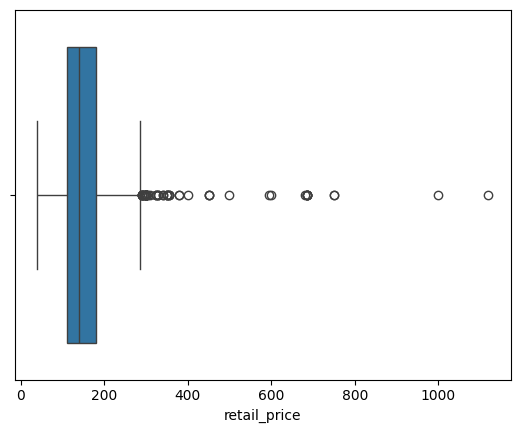

In [89]:
sns.boxplot(
    data=df_limpio,
    x='retail_price'
    )

plt.show()

In [90]:

valor_relleno = df_limpio['retail_price'].median() - df_limpio['retail_price'].std()


df_limpio['retail_price'] = df_limpio['retail_price'].fillna(valor_relleno)

In [91]:
df_limpio.isna().sum()

title           0
sales_series    0
retail_price    0
release_date    0
dtype: int64

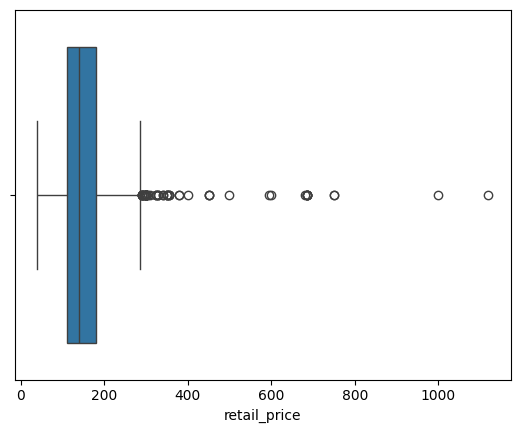

In [92]:
sns.boxplot(
    data=df_limpio,
    x='retail_price'
    )

plt.show()

### Drop sneakers without temporal data

In [93]:
df_limpio = df_limpio[~(df_limpio['sales_series'].str.len() == 0)]

In [94]:
df_limpio

,title,sales_series,retail_price,release_date
0,Jordan 1 LowMidnight Navy Neutral Grey,"[{'xValue': '2025-03-13T00:00:00.000Z', 'yValu...",125.0,04/20/2025
1,Jordan 1 Retro High OGShattered Backboard (2025),"[{'xValue': '2025-06-26T00:00:00.000Z', 'yValu...",180.0,08/23/2025
2,Jordan 1 Retro High OG SPFragment x Union LA V...,"[{'xValue': '2026-02-01T00:00:00.000Z', 'yValu...",205.0,02/27/2026
3,Jordan 1 Retro HighVirgil Abloh Archive Alaska,"[{'xValue': '2026-03-06T00:00:00.000Z', 'yValu...",230.0,04/03/2026
4,Jordan 1 Retro Low OGBanned,"[{'xValue': '2026-04-09T00:00:00.000Z', 'yValu...",145.0,05/02/2026
...,...,...,...,...
5007,Puma Speedcat OGTeam Light Blue Silver Sky (Wo...,"[{'xValue': '2026-03-27T00:00:00.000Z', 'yValu...",100.0,2026-03-27
5009,Puma Stewie 3 TeamTart Cherry (Women's),"[{'xValue': '2025-12-03T00:00:00.000Z', 'yValu...",120.0,08/01/2024
5010,Puma Talon OGFlat Light Grey,"[{'xValue': '2025-10-21T00:00:00.000Z', 'yValu...",150.0,2025-10-21
5011,Puma x Pokemon Kids' 28L BackpackPuma Black/St...,"[{'xValue': '2026-06-03T00:00:00.000Z', 'yValu...",75.0,04/02/2026


In [95]:
df = df_limpio

## Use correct types

In [96]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4822 entries, 0 to 5012
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   title         4822 non-null   object 
 1   sales_series  4822 non-null   object 
 2   retail_price  4822 non-null   float64
 3   release_date  4822 non-null   object 
dtypes: float64(1), object(3)
memory usage: 188.4+ KB


In [97]:
df['release_date'] = pd.to_datetime(df['release_date'], format='mixed')

In [98]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4822 entries, 0 to 5012
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   title         4822 non-null   object        
 1   sales_series  4822 non-null   object        
 2   retail_price  4822 non-null   float64       
 3   release_date  4822 non-null   datetime64[ns]
dtypes: datetime64[ns](1), float64(1), object(2)
memory usage: 188.4+ KB


In [99]:
df.head()

,title,sales_series,retail_price,release_date
0,Jordan 1 LowMidnight Navy Neutral Grey,"[{'xValue': '2025-03-13T00:00:00.000Z', 'yValu...",125.0,2025-04-20
1,Jordan 1 Retro High OGShattered Backboard (2025),"[{'xValue': '2025-06-26T00:00:00.000Z', 'yValu...",180.0,2025-08-23
2,Jordan 1 Retro High OG SPFragment x Union LA V...,"[{'xValue': '2026-02-01T00:00:00.000Z', 'yValu...",205.0,2026-02-27
3,Jordan 1 Retro HighVirgil Abloh Archive Alaska,"[{'xValue': '2026-03-06T00:00:00.000Z', 'yValu...",230.0,2026-04-03
4,Jordan 1 Retro Low OGBanned,"[{'xValue': '2026-04-09T00:00:00.000Z', 'yValu...",145.0,2026-05-02


In [100]:
zapatillas_repetidas = df[df.duplicated(subset=['title'], keep=False)]
print(df.duplicated(subset=['title']).sum())
zapatillas_repetidas

3


,title,sales_series,retail_price,release_date
1908,ASICS Gel-NYCWhite Oyster Grey,"[{'xValue': '2024-10-07T00:00:00.000Z', 'yValu...",130.0,2024-10-01
1924,ASICS Gel-K1011Black Pure Silver,"[{'xValue': '2025-02-28T00:00:00.000Z', 'yValu...",130.0,2025-02-21
1956,ASICS Gel-K1011Black Pure Silver,"[{'xValue': '2025-10-09T00:00:00.000Z', 'yValu...",130.0,2024-03-01
2278,ASICS Gel-NYCWhite Oyster Grey,"[{'xValue': '2023-07-14T00:00:00.000Z', 'yValu...",130.0,2023-07-14
2459,New Balance 2002RBlack Dark Grey,"[{'xValue': '2024-06-23T00:00:00.000Z', 'yValu...",145.0,2024-07-03
2680,New Balance 2002RBlack Dark Grey,"[{'xValue': '2022-04-20T00:00:00.000Z', 'yValu...",140.0,2022-06-18


In [101]:
df = df.drop_duplicates(subset=['title'], keep='first')

# Feature engineering

## Add brand col

In [102]:
marcas = ['ASICS', 'Puma', 'Nike', 'New Balance', 'Adidas', 'Jordan', 'Vans', 'Onitsuka']
patron_regex = f"({'|'.join(marcas)})"


df['brand'] = df['title'].str.extract(patron_regex, flags=re.IGNORECASE)

mapeo_marcas = {marca.lower(): marca for marca in marcas}
df['brand'] = df['brand'].str.lower().map(mapeo_marcas)

es_yeezy = df['title'].str.contains(r'yeezy|yzy', case=False, na=False, regex=True)
df.loc[es_yeezy, 'brand'] = 'Yeezy'

print(df['brand'].unique())

['Jordan' 'Nike' 'Vans' 'Yeezy' 'Adidas' 'ASICS' 'Onitsuka' 'New Balance'
 'Puma']


D:\Temp\ipykernel_7244\3595933904.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['brand'] = df['title'].str.extract(patron_regex, flags=re.IGNORECASE)
D:\Temp\ipykernel_7244\3595933904.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['brand'] = df['brand'].str.lower().map(mapeo_marcas)


In [103]:
df[df['brand'] == 'Adidas']

,title,sales_series,retail_price,release_date,brand
88,adidas Adizero Evo SLBlack White,"[{'xValue': '2024-11-22T00:00:00.000Z', 'yValu...",150.0,2025-03-20,Adidas
89,adidas Adizero Evo SLWhite Black,"[{'xValue': '2024-10-24T00:00:00.000Z', 'yValu...",150.0,2024-10-25,Adidas
90,adidas AE 1 Low3SSB PE,"[{'xValue': '2025-03-16T00:00:00.000Z', 'yValu...",110.0,2025-04-19,Adidas
91,adidas BallerinaBad Bunny Flamboyan,"[{'xValue': '2026-04-25T00:00:00.000Z', 'yValu...",120.0,2026-05-30,Adidas
92,adidas BW Army LuxBlack Gum,"[{'xValue': '2025-04-04T00:00:00.000Z', 'yValu...",120.0,2025-04-01,Adidas
...,...,...,...,...,...
784,adidas Samba XLGCarbon Grey,"[{'xValue': '2024-11-10T00:00:00.000Z', 'yValu...",100.0,2024-10-01,Adidas
785,adidas SamoaCore Black,"[{'xValue': '2024-10-21T00:00:00.000Z', 'yValu...",80.0,2024-08-13,Adidas
786,adidas Ultra Boost 1.0 ATRTeam Power Red,"[{'xValue': '2025-09-26T00:00:00.000Z', 'yValu...",190.0,2024-10-01,Adidas
787,adidas Ultra BoostLeather Black,"[{'xValue': '2019-11-10T00:00:00.000Z', 'yValu...",180.0,2019-11-27,Adidas


## Add highest_value col

In [104]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4819 entries, 0 to 5012
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   title         4819 non-null   object        
 1   sales_series  4819 non-null   object        
 2   retail_price  4819 non-null   float64       
 3   release_date  4819 non-null   datetime64[ns]
 4   brand         4819 non-null   object        
dtypes: datetime64[ns](1), float64(1), object(3)
memory usage: 225.9+ KB


In [ ]:
def calcular_peaks(row):
    serie = row['sales_series']
    release_date = row['release_date']

    if not serie:
        raise ValueError('Serie vacia')

    serie_df = pd.DataFrame(serie)

    serie_df['xValue'] = pd.to_datetime(serie_df['xValue'], utc=True).dt.tz_localize(None)


    post = serie_df[serie_df['xValue'] >= release_date]
    highest_value = post['yValue'].max() if not post.empty else 0

    pre = serie_df[serie_df['xValue'] < release_date]
    pre_release_peak = pre['yValue'].max() if not pre.empty else 0

    return pd.Series({'highest_value': highest_value, 'pre_release_peak': pre_release_peak})

df[['highest_value', 'pre_release_peak']] = df.apply(calcular_peaks, axis=1)

D:\Temp\ipykernel_7244\2446450600.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[['highest_value', 'pre_release_peak']] = df.apply(calcular_peaks, axis=1)
D:\Temp\ipykernel_7244\2446450600.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[['highest_value', 'pre_release_peak']] = df.apply(calcular_peaks, axis=1)


In [106]:
df.head()

,title,sales_series,retail_price,release_date,brand,highest_value,pre_release_peak
0,Jordan 1 LowMidnight Navy Neutral Grey,"[{'xValue': '2025-03-13T00:00:00.000Z', 'yValu...",125.0,2025-04-20,Jordan,172,137
1,Jordan 1 Retro High OGShattered Backboard (2025),"[{'xValue': '2025-06-26T00:00:00.000Z', 'yValu...",180.0,2025-08-23,Jordan,172,266
2,Jordan 1 Retro High OG SPFragment x Union LA V...,"[{'xValue': '2026-02-01T00:00:00.000Z', 'yValu...",205.0,2026-02-27,Jordan,302,1500
3,Jordan 1 Retro HighVirgil Abloh Archive Alaska,"[{'xValue': '2026-03-06T00:00:00.000Z', 'yValu...",230.0,2026-04-03,Jordan,645,2000
4,Jordan 1 Retro Low OGBanned,"[{'xValue': '2026-04-09T00:00:00.000Z', 'yValu...",145.0,2026-05-02,Jordan,145,334


In [107]:
df.columns

Index(['title', 'sales_series', 'retail_price', 'release_date', 'brand',
       'highest_value', 'pre_release_peak'],
      dtype='object')

In [ ]:
def calcular_features(row):
    serie = row['sales_series']
    retail_price = row['retail_price']
    release_date = row['release_date']


    cols_vacias = {
        'roi_pct': 0, 'current_value': 0, 'is_above_retail': False,
        'pre_release_premium_pct': 0, 'days_to_peak': 0,
        'lowest_value_post_release': 0, 'hype_decay_pct': 0,
        'price_volatility': 0
    }

    if not serie:
        return pd.Series(cols_vacias)

    serie_df = pd.DataFrame(serie)
    serie_df['xValue'] = pd.to_datetime(serie_df['xValue'], utc=True).dt.tz_localize(None)
    serie_df = serie_df.sort_values('xValue')

    current_value = serie_df.iloc[-1]['yValue']

    post = serie_df[serie_df['xValue'] >= release_date]
    pre = serie_df[serie_df['xValue'] < release_date]

    if post.empty:

        return pd.Series({**cols_vacias, 'current_value': current_value})

    highest_value = post['yValue'].max()
    lowest_value_post_release = post['yValue'].min()
    idx_peak = post['yValue'].idxmax()
    fecha_peak = post.loc[idx_peak, 'xValue']

    days_to_peak = (fecha_peak - release_date).days


    price_volatility = post['yValue'].std()
    if pd.isna(price_volatility):
        price_volatility = 0

    roi_pct = (highest_value - retail_price) / retail_price * 100 if retail_price else 0
    is_above_retail = bool(current_value > retail_price)

    if highest_value != 0:
        hype_decay_pct = (highest_value - current_value) / highest_value * 100
    else:
        hype_decay_pct = 0

    if not pre.empty and retail_price:
        pre_release_peak = pre['yValue'].max()
        pre_release_premium_pct = (pre_release_peak - retail_price) / retail_price * 100
    else:
        pre_release_premium_pct = 0

    return pd.Series({
        'roi_pct': roi_pct,
        'current_value': current_value,
        'is_above_retail': is_above_retail,
        'pre_release_premium_pct': pre_release_premium_pct,
        'days_to_peak': days_to_peak,
        'lowest_value_post_release': lowest_value_post_release,
        'hype_decay_pct': hype_decay_pct,
        'price_volatility': price_volatility
    })

nuevas_cols = df.apply(calcular_features, axis=1)
df[nuevas_cols.columns] = nuevas_cols


cols_numericas = ['roi_pct', 'current_value', 'pre_release_premium_pct',
                   'days_to_peak', 'lowest_value_post_release',
                   'hype_decay_pct', 'price_volatility']
df[cols_numericas] = df[cols_numericas].fillna(0).astype(float)
df['is_above_retail'] = df['is_above_retail'].fillna(False).astype(bool)

D:\Temp\ipykernel_7244\3108834054.py:70: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[nuevas_cols.columns] = nuevas_cols
D:\Temp\ipykernel_7244\3108834054.py:70: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[nuevas_cols.columns] = nuevas_cols
D:\Temp\ipykernel_7244\3108834054.py:70: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-d

In [109]:
df.isna().sum()

title                        0
sales_series                 0
retail_price                 0
release_date                 0
brand                        0
highest_value                0
pre_release_peak             0
roi_pct                      0
current_value                0
is_above_retail              0
pre_release_premium_pct      0
days_to_peak                 0
lowest_value_post_release    0
hype_decay_pct               0
price_volatility             0
dtype: int64

In [110]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4819 entries, 0 to 5012
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   title                      4819 non-null   object        
 1   sales_series               4819 non-null   object        
 2   retail_price               4819 non-null   float64       
 3   release_date               4819 non-null   datetime64[ns]
 4   brand                      4819 non-null   object        
 5   highest_value              4819 non-null   int64         
 6   pre_release_peak           4819 non-null   int64         
 7   roi_pct                    4819 non-null   float64       
 8   current_value              4819 non-null   float64       
 9   is_above_retail            4819 non-null   bool          
 10  pre_release_premium_pct    4819 non-null   float64       
 11  days_to_peak               4819 non-null   float64       
 12  lowest_valu

In [111]:
df.sample(2)

,title,sales_series,retail_price,release_date,brand,highest_value,pre_release_peak,roi_pct,current_value,is_above_retail,pre_release_premium_pct,days_to_peak,lowest_value_post_release,hype_decay_pct,price_volatility
3371,Nike Mercurial Superfly 10 Elite FGScary Good ...,"[{'xValue': '2025-07-24T00:00:00.000Z', 'yValu...",295.0,2025-07-14,Nike,359,0,21.694915,88.0,False,0.000000,29.0,81.0,75.487465,72.408585
3481,NikeCraft General Purpose ShoeTom Sachs,"[{'xValue': '2022-03-15T00:00:00.000Z', 'yValu...",110.0,2022-06-10,Nike,392,1086,256.363636,185.0,True,887.272727,21.0,124.0,52.806122,59.721729


# Variable Dictionary

| Variable | Type | Description |
|---|---|---|
| `title` | string | Product title/name (sneaker model) as it appears in the original source. |
| `sales_series` | list[dict] | Time series of prices with structure `[{'xValue': iso_date, 'yValue': price}, ...]`. Includes both pre-release (speculation) and post-release data points. |
| `retail_price` | float | Official retail price (launch price). |
| `release_date` | datetime | Official release date of the product. |
| `brand` | string | Normalized brand extracted from the title (e.g. `Yeezy`, `Nike`, `Adidas`, `Jordan`, etc.). |
| `highest_value` | float | Maximum price reached **using only post-release data** (excludes pre-release speculation). |
| `pre_release_peak` | float | Maximum price reached **before release**, reflecting the level of speculation/hype prior to the official launch. `0` if there is no pre-release data. |
| `roi_pct` | float | Percentage return on investment: `(highest_value - retail_price) / retail_price * 100`. Indicates the potential gain if resold at the post-release peak price. `0` if `retail_price` is invalid. |
| `current_value` | float | Most recent price recorded in `sales_series` (last chronological point across the entire series, pre and post). |
| `is_above_retail` | bool | Indicates whether `current_value` exceeds `retail_price` (`True`/`False`). |
| `pre_release_premium_pct` | float | Pre-release speculative premium percentage: `(pre_release_peak - retail_price) / retail_price * 100`. `0` if there was no recorded speculation or `retail_price` is invalid. |
| `days_to_peak` | int | Number of days between `release_date` and the date `highest_value` was reached (always ≥ 0, since it is measured on post-release data). |
| `lowest_value_post_release` | float | Minimum price recorded **after** release. |
| `hype_decay_pct` | float | Percentage drop in price from the peak to the current value: `(highest_value - current_value) / highest_value * 100`. Higher values indicate the initial hype "deflated" over time. |
| `price_volatility` | float | Standard deviation of post-release prices. Measures how unstable/volatile the resale price is. `0` if there is only one or no post-release data points. |

In [ ]:
# df.to_pickle(Path('..')/ Path('data')/Path('clean_data.pkl'))